# Observations

Compares all benchmark methods (Persistence P, Persistence P°, BLEND, AR-OLS, ELM OLS, ELM Ridge) to the ground truth over 3 days per season, for the 5 horizons (0.5 h / 1 h / 3 h / 6 h / 10 h).

- Section 3: all methods on the same 4 seasons × 5 horizons grid.
- Section 4: Ridge vs OLS directly on the same plot with the ground truth.
- Data: files `results/Predictions_*.csv` (generated by `scripts/run_full.py`).
- Assumption: predictions in FULL MODE (`Ndata = round(2 * 365.25 * 48) = 35064`, `LB_list=[48]`, `FH_list=[1,2,6,12,20]`, `ratio=0.5`).

In [43]:
from math import floor
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ROOT       = Path.cwd().parent
RESULTS    = ROOT / 'results'
FIG_DIR    = ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)

# Must match the FULL MODE of the dr_elm_*.py scripts
DATA_START = pd.Timestamp('2020-08-01 00:00:00')
STEP       = pd.Timedelta(minutes=30)
Ndata      = round(2 * 365.25 * 48)
LB         = 48
RATIO      = 0.5

METHODS_TO_PLOT = ['BLEND_est', 'AR_OLS', 'ELM']
FH_TO_PLOT      = [1, 2, 6, 12, 20]     # 30 min / 1 h / 3 h / 6 h / 10 h (horizons)
DAYS_PER_SEASON = 3

# Files per ELM variant — AR-OLS and BLEND are loaded separately and merged
PRED_FILES = {
    'OLS'  : RESULTS / 'Predictions_DR_ELM_ols.csv',
    'Ridge': RESULTS / 'Predictions_DR_ELM_ridge.csv',
}
PRED_AR_OLS      = RESULTS / 'Predictions_AR_OLS.csv'
PRED_BLEND_OPTI  = RESULTS / 'Predictions_BLEND_optimisation.csv'
PRED_BLEND_CORRE = RESULTS / 'Predictions_BLEND_correlation.csv'

SEASONS = {
    'Winter'   : (12,  1,  2),
    'Spring'   : ( 3,  4,  5),
    'Summer'   : ( 6,  7,  8),
    'Autumn'   : ( 9, 10, 11),
}

## 1. Timestamp reconstruction

The predictions CSV stores `t_index` (0..n_test-1) without a date. The target timestamp is reconstructed from the script configuration:

```
n_windows = Ndata - LB - FH + 1
idx_split = floor(RATIO * n_windows)
offset    = idx_split + LB + FH - 1            # index in the resampled array
ts(k)     = DATA_START + (offset + k) * 30min  # with k = t_index
```

In [44]:
def add_timestamps(df: pd.DataFrame) -> pd.DataFrame:
    """Add the `ts` column (timestamp of the y_true target) to the DataFrame."""
    out = []
    for (lb_days, fh_hours), g in df.groupby(['LB_days', 'FH_hours']):
        lb = int(round(lb_days * 48))
        fh = int(round(fh_hours / 0.5))
        n_windows = Ndata - lb - fh + 1
        idx_split = floor(RATIO * n_windows)
        offset    = idx_split + lb + fh - 1
        g = g.copy()
        g['ts'] = DATA_START + (offset + g['t_index'].to_numpy()) * STEP
        out.append(g)
    return pd.concat(out, ignore_index=True)

# One dict per source: name --> DataFrame with the Method column renamed if needed
preds = {}

for name, path in PRED_FILES.items():
    if not path.exists():
        print(f'[skip] {name}: {path} not found')
        continue
    df = pd.read_csv(path)
    df['Method'] = df['Method'].replace('ELM_full', 'ELM')
    df = df[df['Method'] == 'ELM'].copy()
    df = add_timestamps(df)
    preds[name] = df
    print(f'{name}: {len(df):,} rows  methods={sorted(df.Method.unique())}')

# AR-OLS + the two BLEND variants (optimisation and correlation)
EXTRA_SOURCES = [
    ('AR-OLS',     PRED_AR_OLS,      'AR_OLS'),
    ('BLEND_opti', PRED_BLEND_OPTI,  'BLEND_opti'),
    ('BLEND_corre', PRED_BLEND_CORRE, 'BLEND_corre'),
]
for name, path, method_col in EXTRA_SOURCES:
    if not path.exists():
        print(f'[skip] {name}: {path} not found')
        continue
    df = pd.read_csv(path)
    df = df[df['Method'] == method_col].copy()
    df = add_timestamps(df)
    preds[name] = df
    print(f'{name}: {len(df):,} rows  methods={sorted(df.Method.unique())}')

OLS: 87,524 rows  methods=['ELM']
Ridge: 87,524 rows  methods=['ELM']
AR-OLS: 87,524 rows  methods=['AR_OLS']
BLEND_opti: 87,524 rows  methods=['BLEND_opti']
BLEND_corre: 87,524 rows  methods=['BLEND_corre']


## 2. Selecting 3 days per season

Within the test period, we look for **a contiguous block of 3 days** in each meteorological season. For reproducibility the first available block is taken — modify `pick_window` for a different criterion (sunniest day, etc.).

In [45]:
def pick_window(ts_series: pd.Series, months: tuple, n_days: int = DAYS_PER_SEASON):
    """First contiguous block of `n_days` days where all days fall within `months`."""
    days = pd.Series(ts_series.dt.normalize().unique()).sort_values().reset_index(drop=True)
    days_in = days[days.dt.month.isin(months)].reset_index(drop=True)
    if len(days_in) < n_days:
        return None
    for i in range(len(days_in) - n_days + 1):
        window = days_in.iloc[i:i + n_days]
        if (window.iloc[-1] - window.iloc[0]).days == n_days - 1:
            start = window.iloc[0]
            end   = start + pd.Timedelta(days=n_days)
            return start, end
    return None

# Sanity check on the first available dataset
if preds:
    sample = next(iter(preds.values()))
    for season, months in SEASONS.items():
        w = pick_window(sample['ts'], months)
        print(f'{season:10s}: {w}')


Winter    : (Timestamp('2021-12-01 00:00:00'), Timestamp('2021-12-04 00:00:00'))
Spring    : (Timestamp('2022-03-01 00:00:00'), Timestamp('2022-03-04 00:00:00'))
Summer    : (Timestamp('2021-08-01 00:00:00'), Timestamp('2021-08-04 00:00:00'))
Autumn    : (Timestamp('2021-09-01 00:00:00'), Timestamp('2021-09-04 00:00:00'))


## 3. One figure per model vs ground truth

**4 seasons × 5 horizons** grid for each of the four models: ELM OLS, ELM Ridge, AR-OLS, BLEND.

Saved: /home/martin/M1/Stage/python_prediction/figures/pred_vs_truth_ols.png


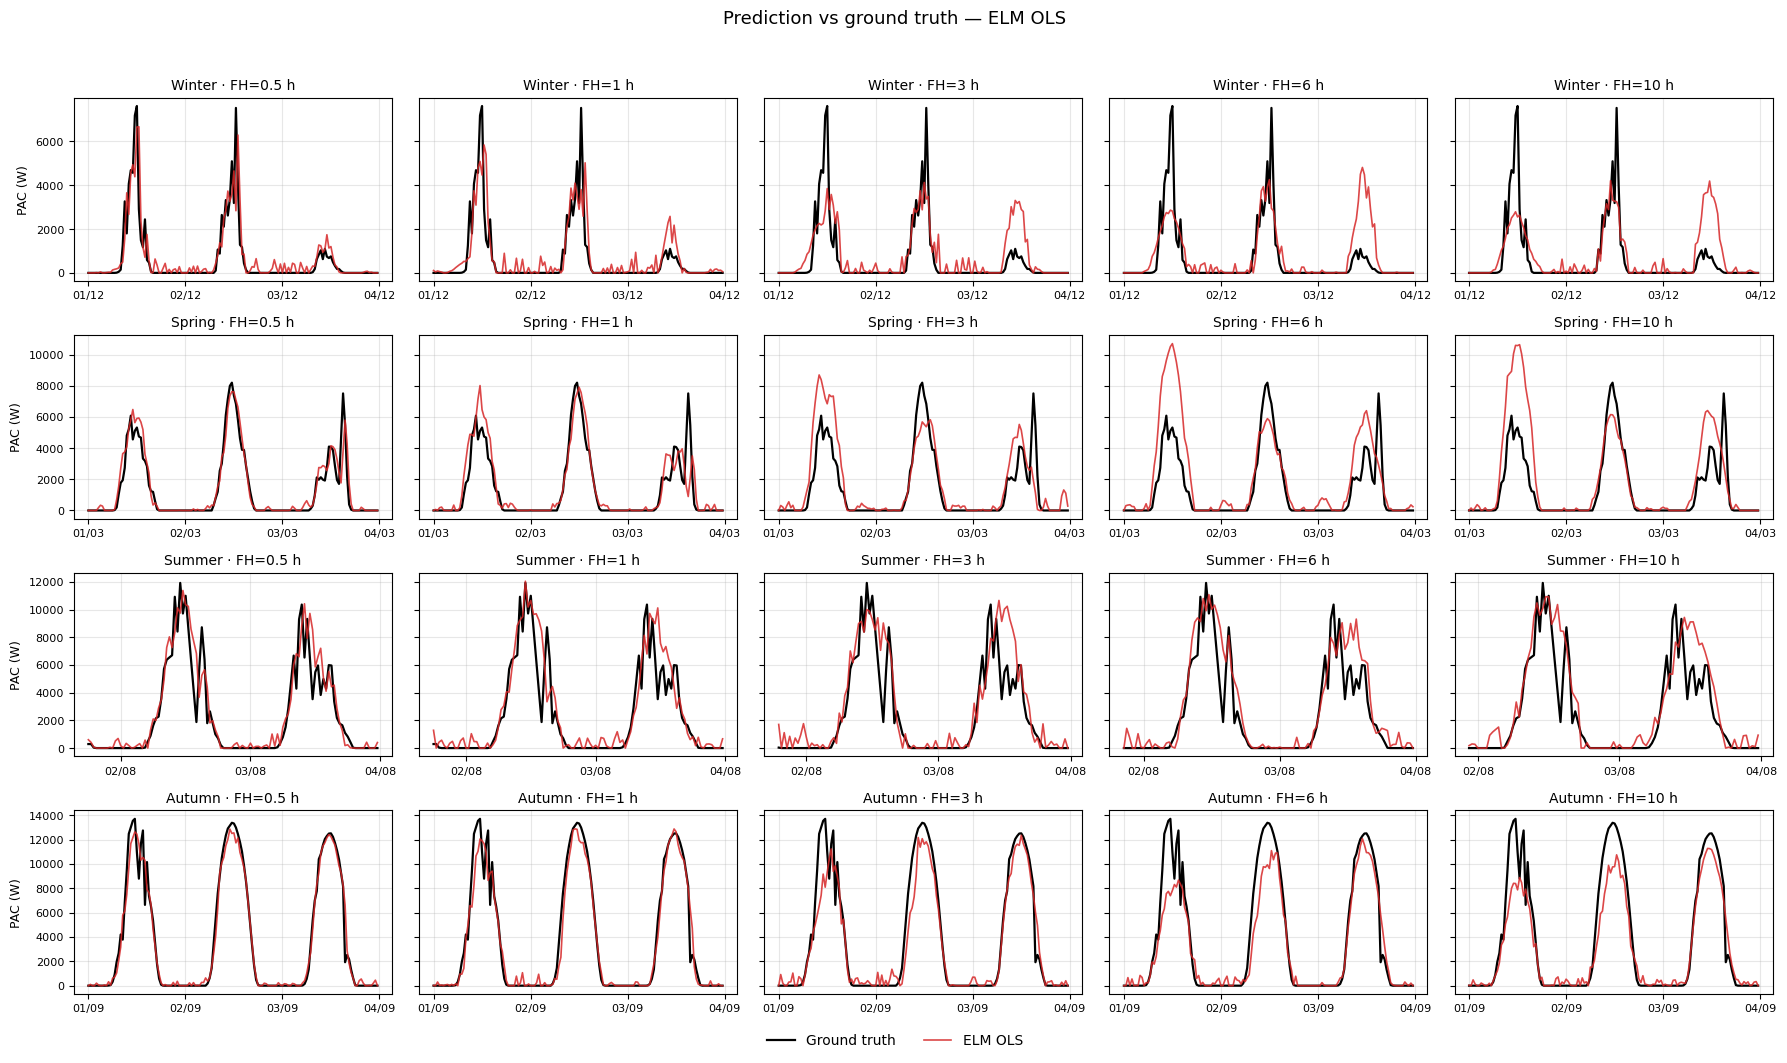

Saved: /home/martin/M1/Stage/python_prediction/figures/pred_vs_truth_ridge.png


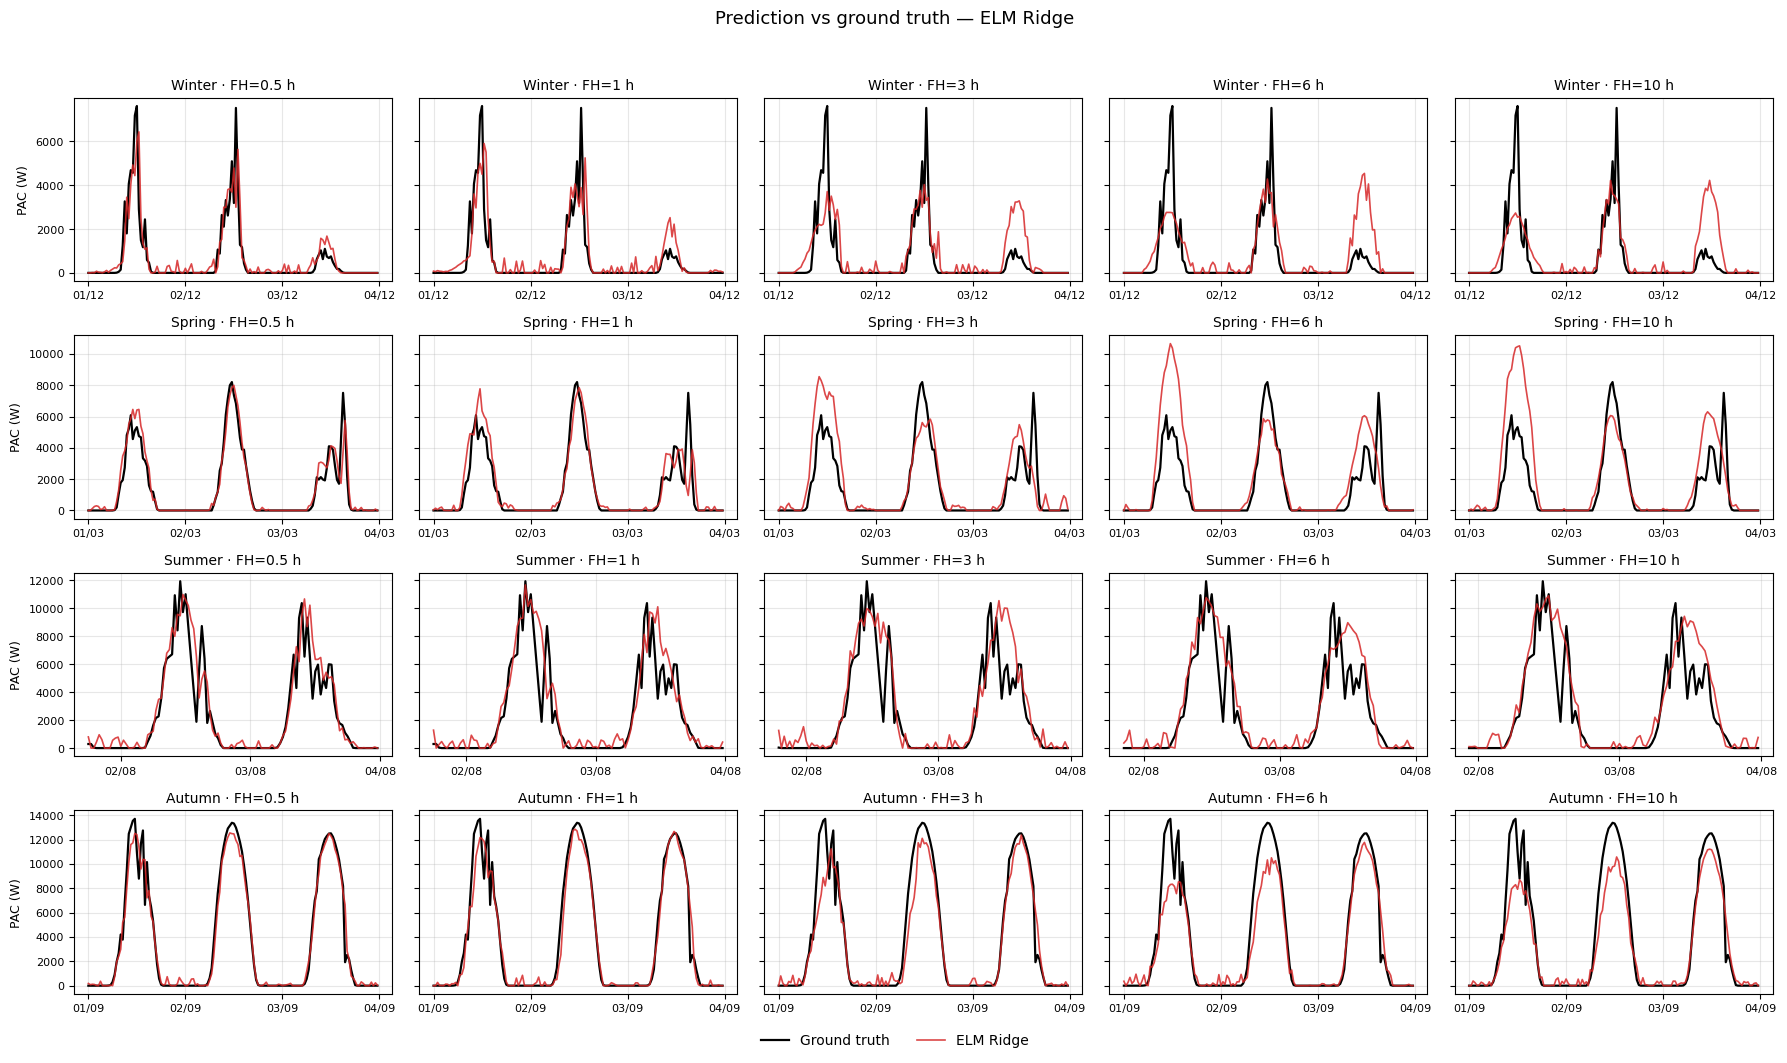

Saved: /home/martin/M1/Stage/python_prediction/figures/pred_vs_truth_ar_ols.png


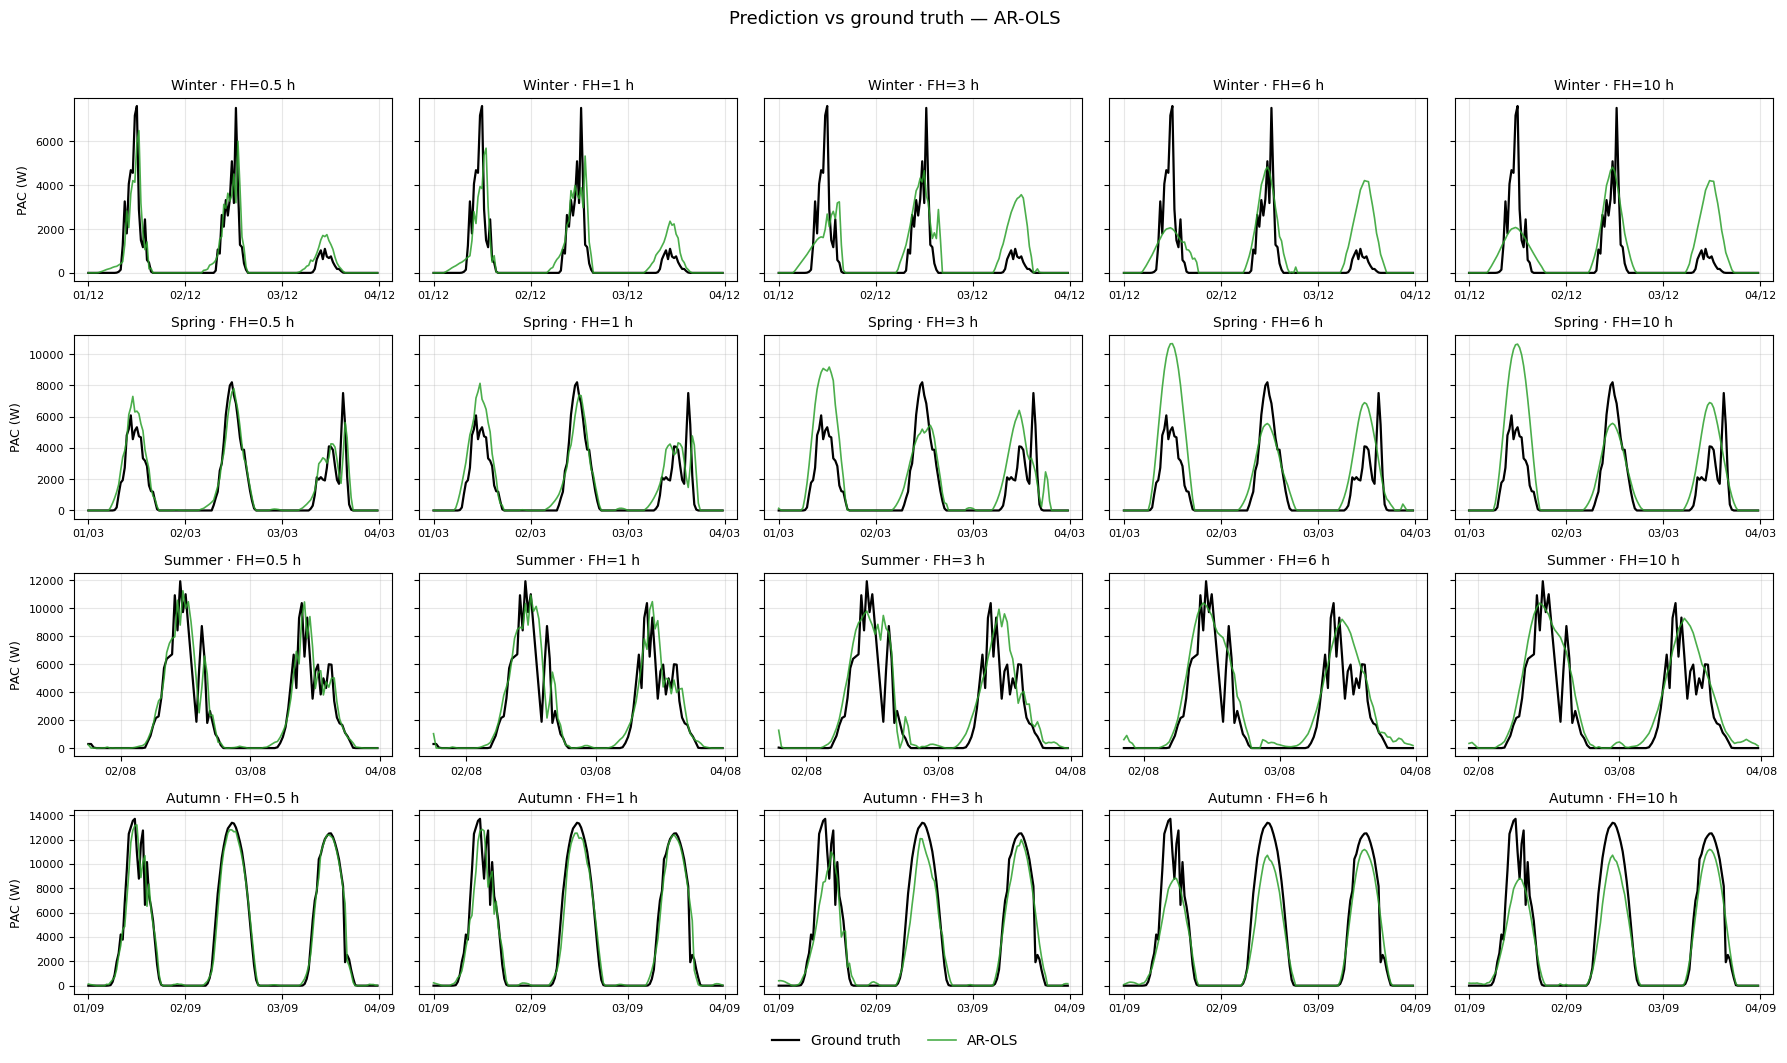

Saved: /home/martin/M1/Stage/python_prediction/figures/pred_vs_truth_blend_opti.png


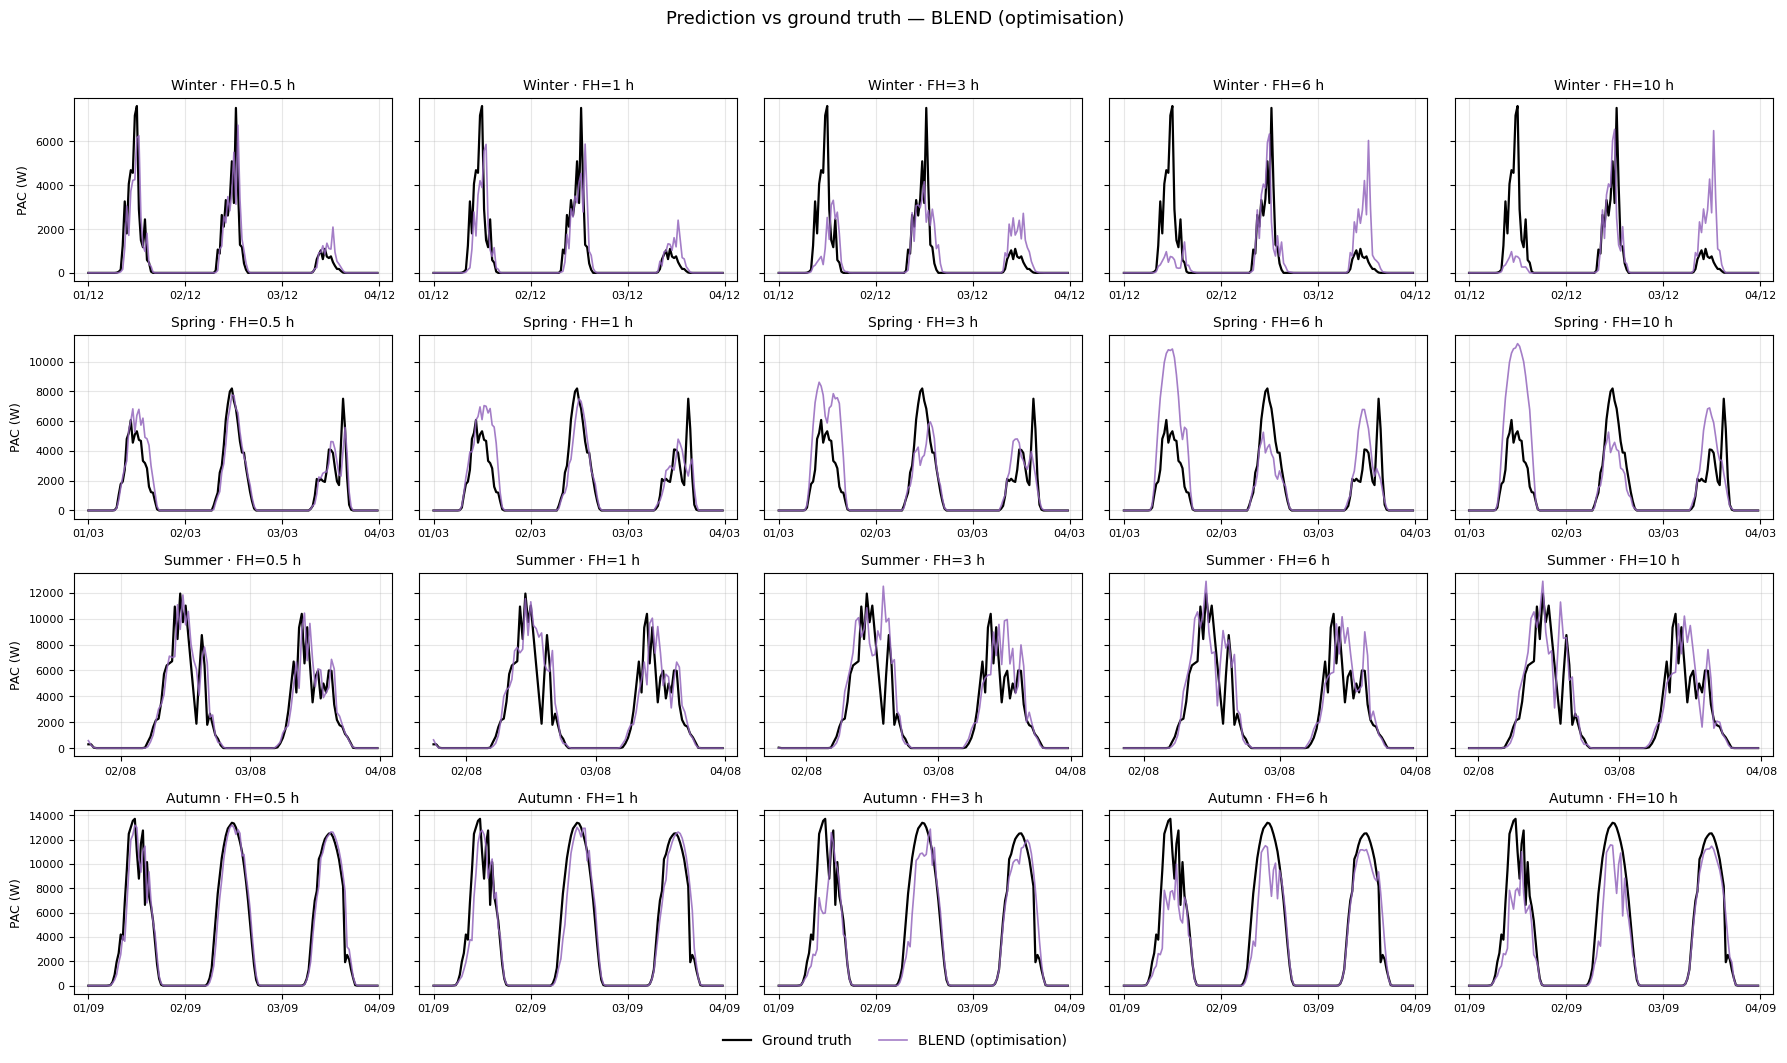

Saved: /home/martin/M1/Stage/python_prediction/figures/pred_vs_truth_blend_corre.png


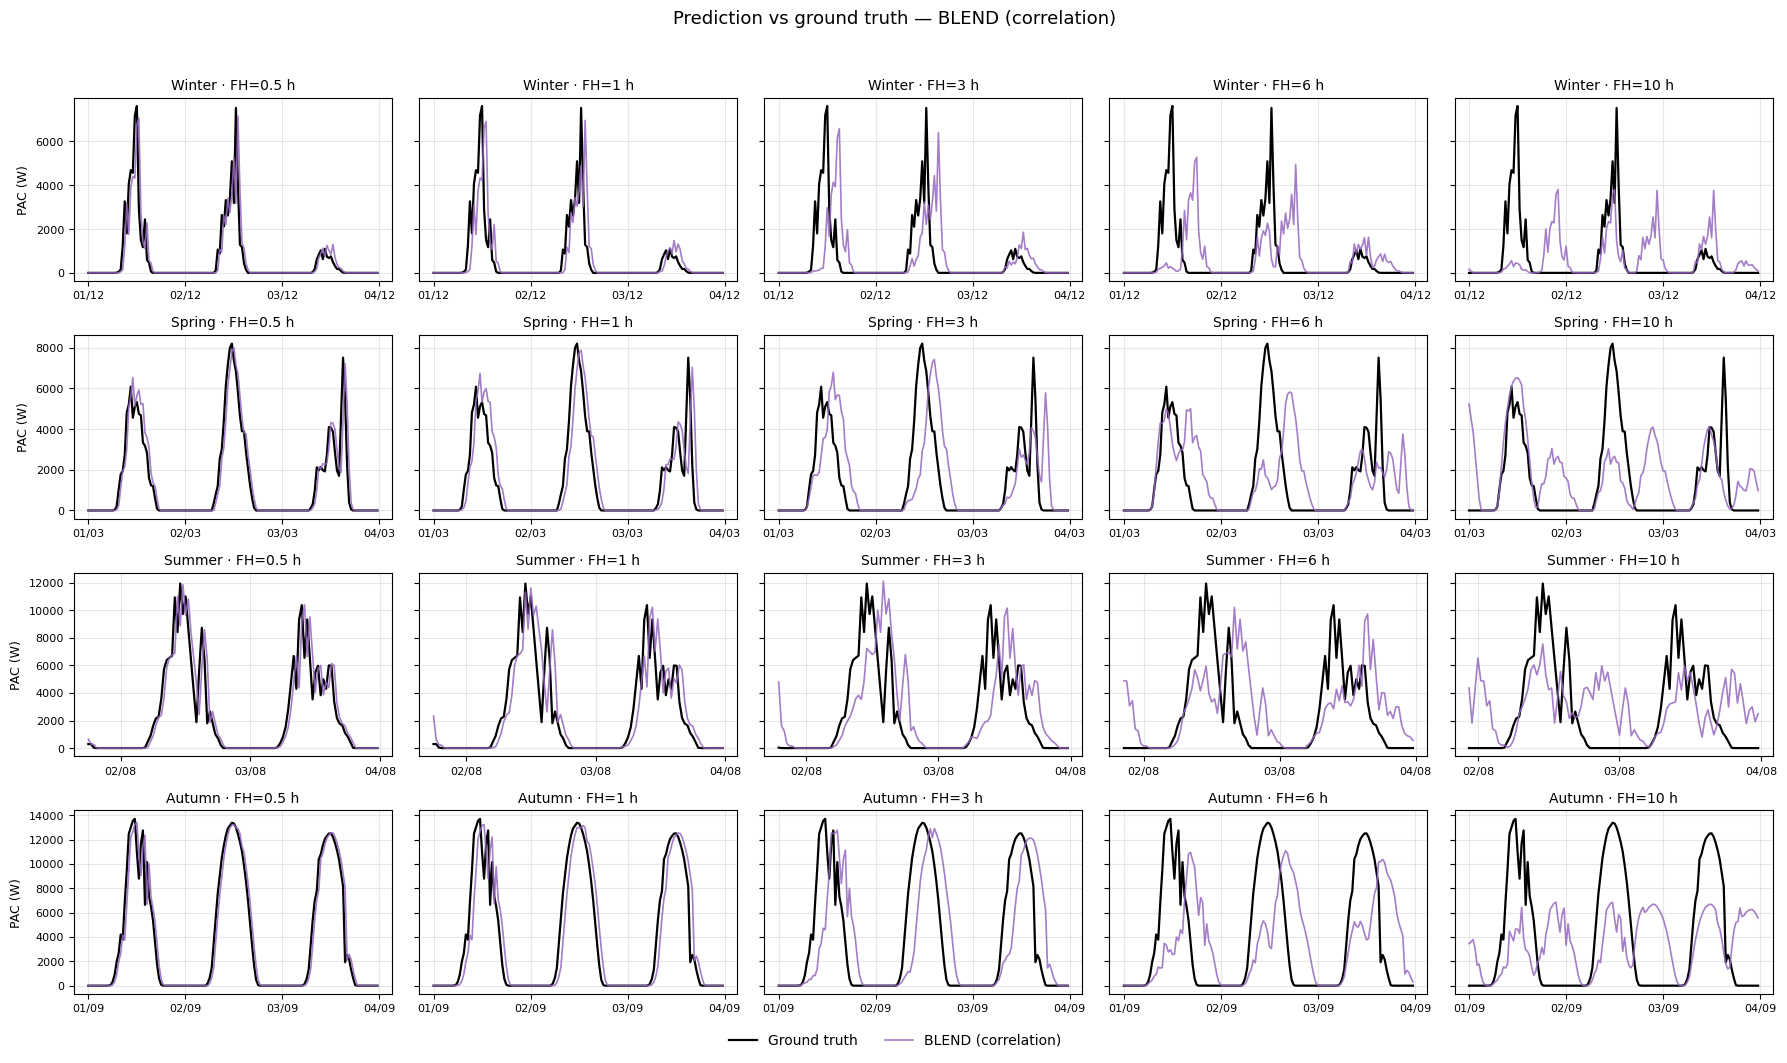

In [46]:
METHOD_STYLES = {
    'ELM'      : dict(color='#d62728', linewidth=1.2, alpha=0.85),
    'AR_OLS'   : dict(color='#2ca02c', linewidth=1.2, alpha=0.85),
    'BLEND_est': dict(color='#1f77b4', linewidth=1.2, alpha=0.85),
}
GT_STYLE = dict(color='black', linewidth=1.6, label='Ground truth')

DISPLAY_NAMES = {
    'OLS'        : 'ELM OLS',
    'Ridge'      : 'ELM Ridge',
    'AR-OLS'     : 'AR-OLS',
    'BLEND_opti' : 'BLEND (optimisation)',
    'BLEND_corre': 'BLEND (correlation)',
}

def plot_single(df: pd.DataFrame, variant_name: str):
    """A 4 seasons × 5 horizons figure for a single model vs ground truth."""
    method_col = df['Method'].iloc[0]
    style = METHOD_STYLES.get(method_col, dict(color='#9467bd', linewidth=1.2, alpha=0.85))
    label = DISPLAY_NAMES.get(variant_name, variant_name)

    n_rows, n_cols = len(SEASONS), len(FH_TO_PLOT)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(3.6 * n_cols, 2.6 * n_rows),
                             sharey='row', squeeze=False)

    for r, (season, months) in enumerate(SEASONS.items()):
        win = pick_window(df['ts'], months)
        for c, fh in enumerate(FH_TO_PLOT):
            ax = axes[r, c]
            fh_hours = fh * 0.5
            sub = df[df['FH_hours'] == fh_hours]
            if win is None or sub.empty:
                ax.set_axis_off()
                ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                        transform=ax.transAxes, fontsize=9, color='gray')
                continue
            start, end = win
            sub = sub[(sub['ts'] >= start) & (sub['ts'] < end)].sort_values('ts')

            ax.plot(sub['ts'], sub['y_true'], **GT_STYLE)
            ax.plot(sub['ts'], sub['y_pred'], label=label, **style)

            ax.set_title(f'{season} · FH={fh_hours:g} h', fontsize=10)
            ax.xaxis.set_major_locator(mdates.DayLocator())
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
            ax.tick_params(axis='x', rotation=0, labelsize=8)
            ax.tick_params(axis='y', labelsize=8)
            ax.grid(True, alpha=0.3)
            if c == 0:
                ax.set_ylabel('PAC (W)', fontsize=9)

    handles, labels = next(
        ((ax.get_legend_handles_labels()) for row in axes for ax in row if ax.get_legend_handles_labels()[0]),
        ([], [])
    )
    if handles:
        fig.legend(handles, labels, loc='lower center', ncol=len(labels),
               bbox_to_anchor=(0.5, -0.01), frameon=False, fontsize=10)
    fig.suptitle(f'Prediction vs ground truth — {label}', fontsize=13, y=1.00)
    fig.tight_layout(rect=[0, 0.02, 1, 0.98])

    fname = variant_name.lower().replace('-', '_').replace(' ', '_')
    out = FIG_DIR / f'pred_vs_truth_{fname}.png'
    fig.savefig(out, dpi=130, bbox_inches='tight')
    print(f'Saved: {out}')
    plt.show()

for name, df in preds.items():
    plot_single(df, name)

## 4. Ridge vs OLS — direct comparison with the ground truth

Same **4 seasons × 5 horizons** grid, but the two curves are `ELM_OLS` and `ELM_Ridge` (plus the ground truth).


Saved: /home/martin/M1/Stage/python_prediction/figures/pred_vs_truth_ridge_vs_ols.png


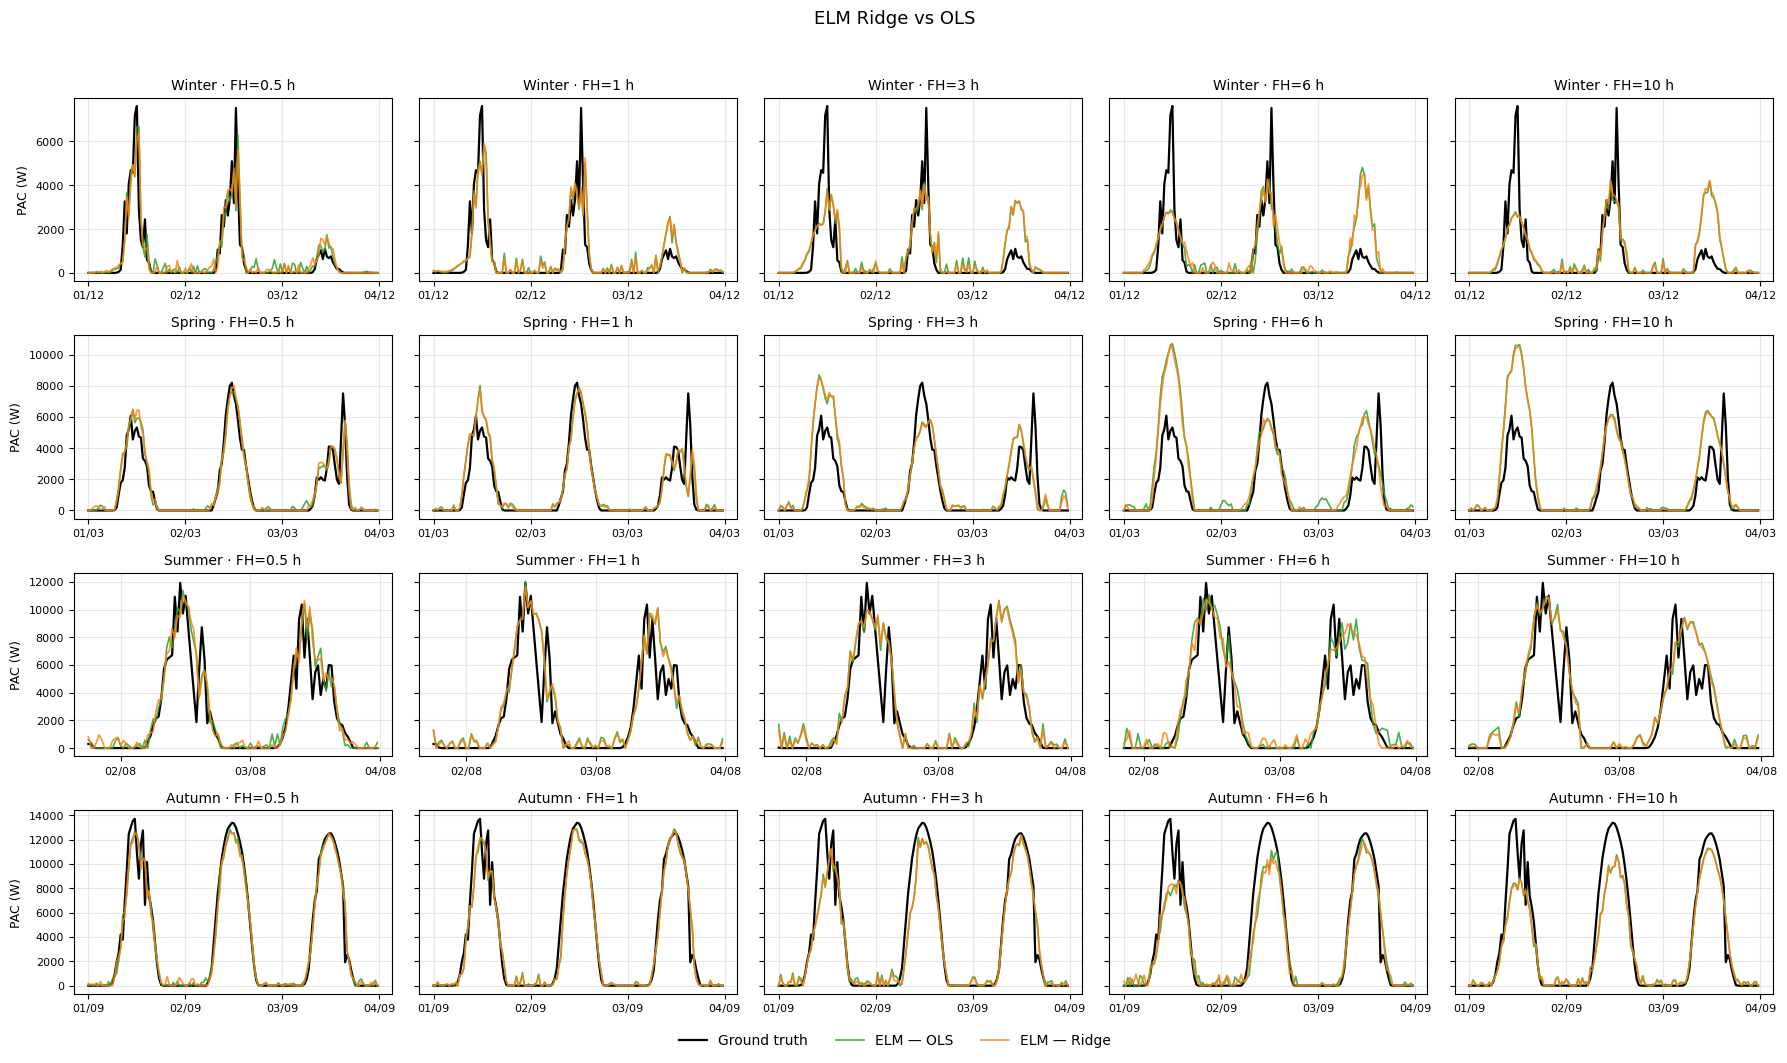

In [47]:
STYLES_COMPARE = {
    'y_true'   : dict(color='black',   linewidth=1.6, label='Ground truth'),
    'ELM_OLS'  : dict(color='#2ca02c', linewidth=1.2, alpha=0.85, label='ELM — OLS'),
    'ELM_Ridge': dict(color='#ff7f0e', linewidth=1.2, alpha=0.85, label='ELM — Ridge'),
}

if len(preds) < 2:
    print('[skip] Both files (OLS and Ridge) are required for this section.')
else:
    df_ols   = preds['OLS'][preds['OLS']['Method'] == 'ELM'].copy()
    df_ridge = preds['Ridge'][preds['Ridge']['Method'] == 'ELM'].copy()

    n_rows, n_cols = len(SEASONS), len(FH_TO_PLOT)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(3.6 * n_cols, 2.6 * n_rows),
                             sharey='row', squeeze=False)

    for r, (season, months) in enumerate(SEASONS.items()):
        win = pick_window(df_ols['ts'], months)
        for c, fh in enumerate(FH_TO_PLOT):
            ax = axes[r, c]
            fh_hours = fh * 0.5

            sub_ols   = df_ols[df_ols['FH_hours'] == fh_hours]
            sub_ridge = df_ridge[df_ridge['FH_hours'] == fh_hours]

            if win is None or sub_ols.empty:
                ax.set_axis_off()
                continue
            start, end = win
            sub_ols   = sub_ols[(sub_ols['ts'] >= start)   & (sub_ols['ts'] < end)].sort_values('ts')
            sub_ridge = sub_ridge[(sub_ridge['ts'] >= start) & (sub_ridge['ts'] < end)].sort_values('ts')

            ax.plot(sub_ols['ts'],   sub_ols['y_true'],  **STYLES_COMPARE['y_true'])
            ax.plot(sub_ols['ts'],   sub_ols['y_pred'],  **STYLES_COMPARE['ELM_OLS'])
            ax.plot(sub_ridge['ts'], sub_ridge['y_pred'], **STYLES_COMPARE['ELM_Ridge'])

            ax.set_title(f'{season} · FH={fh_hours:g} h', fontsize=10)
            ax.xaxis.set_major_locator(mdates.DayLocator())
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
            ax.tick_params(axis='x', rotation=0, labelsize=8)
            ax.tick_params(axis='y', labelsize=8)
            ax.grid(True, alpha=0.3)
            if c == 0:
                ax.set_ylabel('PAC (W)', fontsize=9)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=len(labels),
               bbox_to_anchor=(0.5, -0.01), frameon=False, fontsize=10)
    fig.suptitle('ELM Ridge vs OLS', fontsize=13, y=1.00)
    fig.tight_layout(rect=[0, 0.02, 1, 0.98])

    out = FIG_DIR / 'pred_vs_truth_ridge_vs_ols.png'
    fig.savefig(out, dpi=130, bbox_inches='tight')
    print(f'Saved: {out}')
    plt.show()

## 5. Clear day vs cloudy day

Two days chosen automatically within the test period, at **FH = 1 h**, with the three models (BLEND, AR-OLS, ELM) overlaid on the ground truth.

- **Clear day**: a summer day whose PAC curve is closest to a smooth bell shape (low relative noise around a Gaussian smoothing).
- **Cloudy day**: a day whose daytime PAC curve shows the most rapid variations (high relative roughness).

In [48]:
FH_SLIDE = 1  # FH=1 => 0.5 h; we want 1 h => FH index = 2
FH_SLIDE_HOURS = 1.0

# Build a "long" DataFrame with one column per model for FH=1h
def build_long_fh(fh_hours: float) -> pd.DataFrame:
    """Gather y_true + one y_pred column per model, indexed by ts, for a given FH."""
    parts = {}
    for key, df in preds.items():
        sub = df[df['FH_hours'] == fh_hours].copy()
        if sub.empty:
            continue
        sub = sub.set_index('ts')[['y_true', 'y_pred']]
        parts[key] = sub
    if not parts:
        return pd.DataFrame()
    # Take y_true from the first (all identical at the same ts)
    ref_key = next(iter(parts))
    out = parts[ref_key][['y_true']].copy()
    for key, sub in parts.items():
        out[key] = sub['y_pred']
    return out.dropna().sort_index()

long_fh = build_long_fh(FH_SLIDE_HOURS)
print(f'FH={FH_SLIDE_HOURS} h  -> {len(long_fh):,} steps, columns={list(long_fh.columns)}')
print(f'Test period : {long_fh.index.min()}  ->  {long_fh.index.max()}')

FH=1.0 h  -> 17,508 steps, columns=['y_true', 'OLS', 'Ridge', 'AR-OLS', 'BLEND_opti', 'BLEND_corre']
Test period : 2021-08-01 18:00:00  ->  2022-08-01 11:30:00


In [49]:
# Automatic selection of the two days
# - clear  : max peak AND low roughness (rapid variations)
# - cloudy : peak >= 30% of the climatological max AND high roughness

if long_fh.empty or 'y_true' not in long_fh.columns:
    print('[skip] long_fh is empty — run the cells above to load prediction files first.')
else:
    def daily_features(s_day: pd.Series) -> dict:
        """Return peak, energy, and 'roughness' = mean of |Δ| in daytime, normalized by peak."""
        if s_day.empty:
            return dict(peak=0.0, energy=0.0, rough=0.0)
        peak = float(s_day.max())
        energy = float(s_day.sum())
        if peak < 1.0:
            return dict(peak=peak, energy=energy, rough=0.0)
        daylight = s_day[s_day > 0.1 * peak]
        if len(daylight) < 4:
            return dict(peak=peak, energy=energy, rough=0.0)
        diffs = np.abs(np.diff(daylight.to_numpy()))
        rough = float(diffs.mean() / peak)
        return dict(peak=peak, energy=energy, rough=rough)

    # Group the ground truth by calendar day
    gt = long_fh['y_true']
    by_day = gt.groupby(gt.index.normalize())

    stats = []
    for day, s in by_day:
        if len(s) < 40:  # incomplete day
            continue
        feat = daily_features(s)
        feat['day'] = day
        stats.append(feat)

    df_days = pd.DataFrame(stats).set_index('day')
    peak_max = df_days['peak'].quantile(0.95)  # "sunny" reference

    # Clear day: high peak + low roughness
    mask_clear = df_days['peak'] >= 0.85 * peak_max
    clear_day = df_days.loc[mask_clear, 'rough'].idxmin()

    # Cloudy day: decent peak (otherwise it's just a winter day) + high roughness
    mask_cloud = df_days['peak'] >= 0.30 * peak_max
    cloud_day = df_days.loc[mask_cloud, 'rough'].idxmax()

    print(f"Clear day  : {clear_day.date()}  "
          f"(peak={df_days.loc[clear_day,'peak']:.0f} W, roughness={df_days.loc[clear_day,'rough']:.3f})")
    print(f"Cloudy day : {cloud_day.date()}  "
          f"(peak={df_days.loc[cloud_day,'peak']:.0f} W, roughness={df_days.loc[cloud_day,'rough']:.3f})")

Clear day  : 2022-06-16  (peak=13530 W, roughness=0.071)
Cloudy day : 2021-11-10  (peak=5101 W, roughness=0.390)


Saved: /home/martin/M1/Stage/python_prediction/figures/slide_journee_claire.png


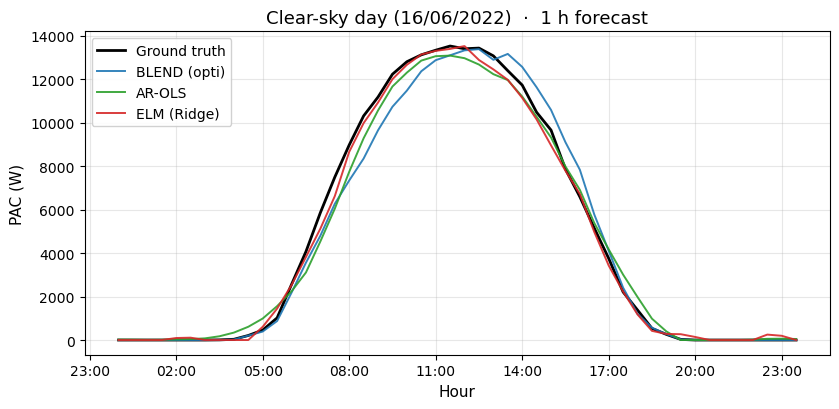

Saved: /home/martin/M1/Stage/python_prediction/figures/slide_journee_nuageuse.png


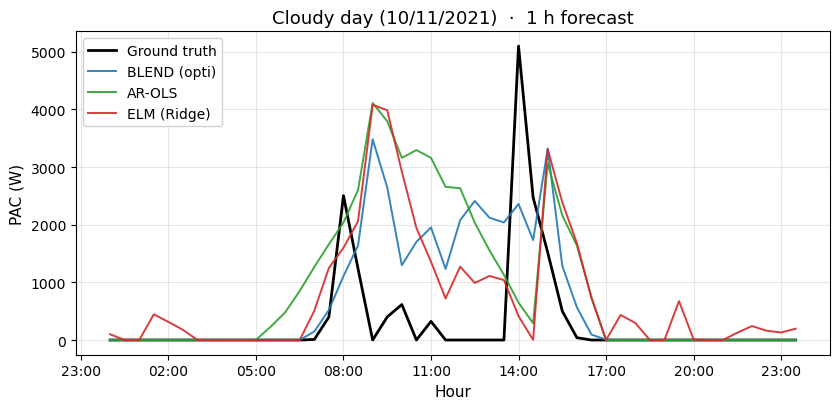

In [50]:
# Plot: one figure per day, 3 models + ground truth, FH=1h
SLIDE_STYLES = {
    'y_true'     : dict(color='black',   linewidth=2.0, label='Ground truth'),
    'BLEND_opti' : dict(color='#1f77b4', linewidth=1.4, alpha=0.9, label='BLEND (opti)'),
    'AR-OLS'     : dict(color='#2ca02c', linewidth=1.4, alpha=0.9, label='AR-OLS'),
    'Ridge'      : dict(color='#d62728', linewidth=1.4, alpha=0.9, label='ELM (Ridge)'),
}
MODEL_ORDER = ['BLEND_opti', 'AR-OLS', 'Ridge']

def plot_day(day: pd.Timestamp, title: str, fname: str) -> None:
    start = day
    end = day + pd.Timedelta(days=1)
    sub = long_fh[(long_fh.index >= start) & (long_fh.index < end)]
    if sub.empty:
        print(f"[skip] no data for {day.date()}")
        return

    fig, ax = plt.subplots(figsize=(8.5, 4.2))
    ax.plot(sub.index, sub['y_true'], **SLIDE_STYLES['y_true'])
    for m in MODEL_ORDER:
        if m in sub.columns:
            ax.plot(sub.index, sub[m], **SLIDE_STYLES[m])

    ax.set_title(f'{title} ({day.strftime("%d/%m/%Y")})  ·  1 h forecast',
                 fontsize=13)
    ax.set_ylabel('PAC (W)', fontsize=11)
    ax.set_xlabel('Hour', fontsize=11)
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
    fig.tight_layout()

    out = FIG_DIR / fname
    fig.savefig(out, dpi=140, bbox_inches='tight')
    print(f'Saved: {out}')
    plt.show()

plot_day(clear_day, 'Clear-sky day',  'slide_journee_claire.png')
plot_day(cloud_day, 'Cloudy day',     'slide_journee_nuageuse.png')

### 5.1 Data overview (1 week of PAC)

A typical week to show the day/night cycle, the day-to-day variability, and the order of magnitude.

In [ ]:
DATA_NPY = ROOT / 'data' / 'Palaiseau' / 'data_30min.npy'
data_full = np.load(DATA_NPY)
ts_full = DATA_START + np.arange(len(data_full)) * STEP

# A summer week for the slide (June 2022)
WEEK_START = pd.Timestamp('2022-06-13')
WEEK_END = WEEK_START + pd.Timedelta(days=7)
mask = (ts_full >= WEEK_START) & (ts_full < WEEK_END)

fig, ax = plt.subplots(figsize=(9.5, 3.6))
ax.plot(ts_full[mask], data_full[mask], color='#d97706', linewidth=1.3)
ax.fill_between(ts_full[mask], 0, data_full[mask], color='#fbbf24', alpha=0.25)
ax.set_title(f'PAC at Palaiseau — week of {WEEK_START.strftime("%d/%m/%Y")} (30-min step)',
             fontsize=13)
ax.set_ylabel('PAC (W)', fontsize=11)
ax.set_xlabel('Date', fontsize=11)
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %d/%m'))
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
fig.tight_layout()
out = FIG_DIR / 'slide_donnees_semaine.png'
fig.savefig(out, dpi=140, bbox_inches='tight')
print(f'Saved: {out}')
plt.show()

### 5.2 Train / test split

Timeline of the 2 years used, split into a chronological 50% train / 50% test.

Saved: /home/martin/M1/Stage/python_prediction/figures/slide_train_test.png


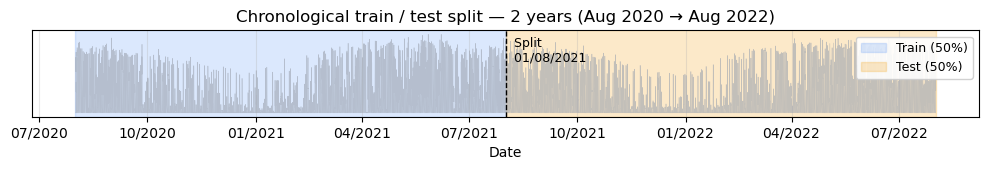

In [52]:
data_used = data_full[:Ndata]
ts_used = DATA_START + np.arange(Ndata) * STEP
split_idx = floor(0.5 * Ndata)
ts_split = ts_used[split_idx]
ts_split_pd = pd.Timestamp(ts_split)

fig, ax = plt.subplots(figsize=(10, 1.8))
ax.plot(ts_used, data_used, color='#9ca3af', linewidth=0.4, alpha=0.6)
ax.axvspan(ts_used[0], ts_split, color='#3b82f6', alpha=0.18, label='Train (50%)')
ax.axvspan(ts_split, ts_used[-1], color='#f59e0b', alpha=0.22, label='Test (50%)')
ax.axvline(ts_split, color='black', linewidth=1.0, linestyle='--')
ax.text(ts_split_pd, ax.get_ylim()[1] * 0.92, f'  Split\n  {ts_split_pd.strftime("%d/%m/%Y")}',
        fontsize=9, va='top')
ax.set_title('Chronological train / test split — 2 years (Aug 2020 → Aug 2022)',
             fontsize=12)
ax.set_xlabel('Date', fontsize=10)
ax.set_yticks([])
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.grid(True, axis='x', alpha=0.3)
fig.tight_layout()
out = FIG_DIR / 'slide_train_test.png'
fig.savefig(out, dpi=140, bbox_inches='tight')
print(f'Saved: {out}')
plt.show()

### 5.3 $NICE^\Sigma$ daytime only as a function of the horizon

One curve per model. Simple persistence = 1 by construction. The lower the curve, the better the model.

Saved: /home/martin/M1/Stage/python_prediction/figures/slide_nice_vs_horizon.png


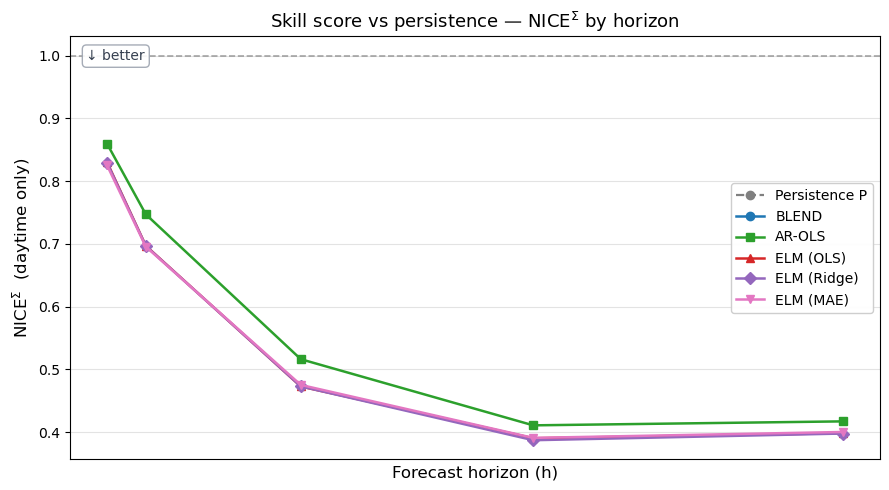


NICE_Sigma (daytime only) by horizon:
          BLEND  AR-OLS  ELM (OLS)  ELM (Ridge)  ELM (MAE)
FH_hours                                                  
0.5         NaN   0.859      0.830        0.829      0.825
1.0         NaN   0.747      0.697        0.697      0.696
3.0         NaN   0.516      0.473        0.473      0.475
6.0         NaN   0.411      0.390        0.387      0.391
10.0        NaN   0.417      0.398        0.398      0.400


In [53]:
RES_FILES = {
    'BLEND'      : RESULTS / 'Results_BLEND_optimisation_day.csv',
    'AR-OLS'     : RESULTS / 'Results_AR_OLS_day.csv',
    'ELM (OLS)'  : RESULTS / 'Results_DR_ELM_ols_day.csv',
    'ELM (Ridge)': RESULTS / 'Results_DR_ELM_ridge_day.csv',
    'ELM (MAE)'  : RESULTS / 'Results_DR_ELM_mae_day.csv',
}
TARGET_METHODS = {
    'BLEND'      : 'BLEND_est',
    'AR-OLS'     : 'AR_OLS',
    'ELM (OLS)'  : 'ELM',
    'ELM (Ridge)': 'ELM',
    'ELM (MAE)'  : 'ELM',
}
CURVE_STYLES = {
    'Persistence' : dict(color='gray',    linewidth=1.6, linestyle='--', marker='o', label='Persistence P'),
    'BLEND'       : dict(color='#1f77b4', linewidth=1.8, marker='o', label='BLEND'),
    'AR-OLS'      : dict(color='#2ca02c', linewidth=1.8, marker='s', label='AR-OLS'),
    'ELM (OLS)'   : dict(color='#d62728', linewidth=1.8, marker='^', label='ELM (OLS)'),
    'ELM (Ridge)' : dict(color='#9467bd', linewidth=1.8, marker='D', label='ELM (Ridge)'),
    'ELM (MAE)'   : dict(color='#e377c2', linewidth=1.8, marker='v', label='ELM (MAE)'),
}

curves: dict[str, pd.DataFrame] = {}
for name, path in RES_FILES.items():
    df = pd.read_csv(path)
    sub = df[df['Method'] == TARGET_METHODS[name]].copy()
    sub = sub.sort_values('FH_hours')
    curves[name] = sub[['FH_hours', 'NICE_Sigma']].reset_index(drop=True)

fh_axis = curves['BLEND']['FH_hours'].to_numpy()

fig, ax = plt.subplots(figsize=(9, 5))
ax.axhline(1.0, color='gray', linewidth=1.2, linestyle='--', alpha=0.7)
ax.plot(fh_axis, np.ones_like(fh_axis), **CURVE_STYLES['Persistence'])
for name in ['BLEND', 'AR-OLS', 'ELM (OLS)', 'ELM (Ridge)', 'ELM (MAE)']:
    c = curves[name]
    ax.plot(c['FH_hours'], c['NICE_Sigma'], **CURVE_STYLES[name])

ax.set_xlabel('Forecast horizon (h)', fontsize=12)
ax.set_ylabel(r'NICE$^\Sigma$  (daytime only)', fontsize=12)
ax.set_title(r'Skill score vs persistence — NICE$^\Sigma$ by horizon', fontsize=13)
ax.set_xticks(fh_axis)
ax.grid(True, alpha=0.35)
ax.legend(loc='center right', fontsize=10, framealpha=0.95)
ax.text(0.02, 0.97, '↓ better', transform=ax.transAxes,
        fontsize=10, va='top', color='#374151',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#9ca3af', alpha=0.9))
fig.tight_layout()
out = FIG_DIR / 'slide_nice_vs_horizon.png'
fig.savefig(out, dpi=140, bbox_inches='tight')
print(f'Saved: {out}')
plt.show()

# Summary table
recap = pd.DataFrame({name: c.set_index('FH_hours')['NICE_Sigma'] for name, c in curves.items()})
print('\nNICE_Sigma (daytime only) by horizon:')
print(recap.round(3).to_string())